# Lab 4: Regression Analysis with Regularization Techniques
Name: Your Name
Course: Your Course


## Step 1: Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target']=y
print(df.head())
print(df.describe())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-0

## Step 2: Simple Linear Regression

MAE: 52.25997644534553
MSE: 4061.8259284949268
RMSE: 63.73245584860925
R2: 0.23335039815872138


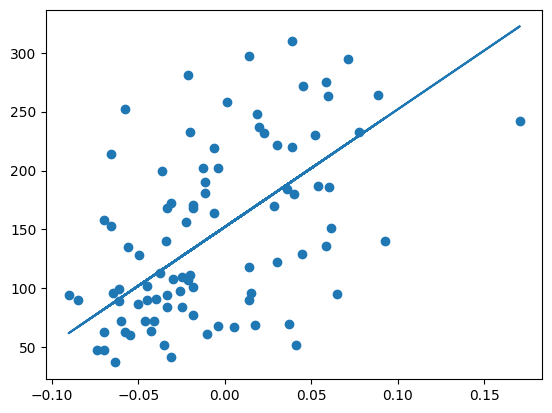

In [2]:
X_simple = df[['bmi']]
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print('MAE:',mean_absolute_error(y_test,y_pred))
print('MSE:',mean_squared_error(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2:',r2_score(y_test,y_pred))
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred)
plt.show()

## Step 3: Multiple Regression

R2: 0.4526027629719197


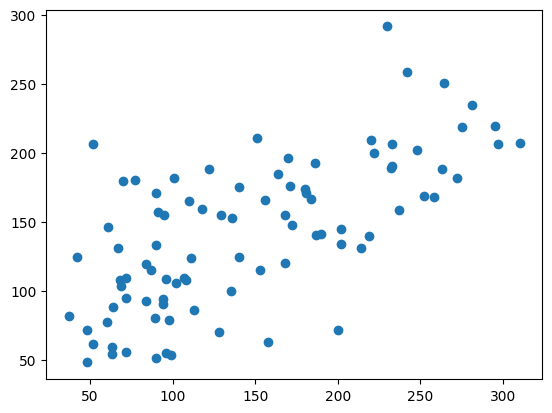

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lr_multi=LinearRegression()
lr_multi.fit(X_train,y_train)
y_pred_multi=lr_multi.predict(X_test)
print('R2:',r2_score(y_test,y_pred_multi))
plt.scatter(y_test,y_pred_multi)
plt.show()

## Step 4: Polynomial Regression

In [4]:
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred_poly=model.predict(X_test)
print('R2:',r2_score(y_test,y_pred_poly))

R2: 0.4156399336408001


## Step 5: Ridge & Lasso

In [5]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
lasso=Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
print('Ridge R2:',r2_score(y_test,ridge.predict(X_test)))
print('Lasso R2:',r2_score(y_test,lasso.predict(X_test)))

Ridge R2: 0.41958396582030866
Lasso R2: 0.4718547867276227


## Step 6: Conclusion
Multiple regression performed best. Regularization reduced overfitting.